In [1]:
import sys, os
import torch
from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram,to_tree
from scipy.spatial import distance_matrix
from abc import ABC, abstractmethod
import numpy as np
import pyro
from pyro import distributions as dist
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from ete3 import Tree,TreeStyle, NodeStyle, faces, AttrFace
import umap

#local_repository=True
#script_dir = os.path.dirname(os.path.abspath(__file__))
# if local_repository:
#     sys.path.insert(1,"/home/lys/Dropbox/PhD/DRAUPNIR_ASR/draupnir/src")
#     sys.path.insert(1,f"{script_dir}/draupnir/src")
#     import draupnir
# else:#pip installed module
#     import draupnir
#from draupnir import str2bool,str2None

/home/lys/y/envs/draupnir_xlstm2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prior predictive posterior model (no observations)

In [19]:
class GPKernel(ABC):
    @abstractmethod
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError

class SquaredExponential_Kernel(GPKernel):

    def __init__(self, signal_variance, len_scale):
        self.signal_variance = signal_variance
        self.len_scale = len_scale

    def forward(self, t: torch.Tensor) -> torch.Tensor:

        len_scale = self.len_scale[:,None,None]
        inner_product  = torch.exp(-t**2 / 2*len_scale)
        signal_variance = self.signal_variance[:,None,None]
        inner_product = (signal_variance**2)*inner_product


        return inner_product

class OUKernel_Fast(GPKernel):
    """ Kernel that computes the covariance matrix for a z Ornstein Ulenbeck processes. As stated in Equation 2.1 https://arxiv.org/pdf/1208.0628.pdf
    :param tensor sigma_f: Quantifies the intensity of inherited variation ---> Signal variance
    :param tensor lamb: Characteristic length-scale of the evolutionary dynamics (equivalent to the inverse of the strength of selection)---> Distance between data points (nodes),larger l implies that the noise should be bigger to capture big point fluctuations
    :param tensor sigma_n:quantifies the intensity of specific variation(i.e. variation unattributable to the phylogeny)--->Gaussian Noise,intensity of specific variation--> how much to let the sequence vary ---> so max branch lengh?
    **References:**
    "Ancestral Inference from Functional Data: Statistical Methods and Numerical Examples"
    """
    def __init__(self, sigma_f, lambd, sigma_n = None, z_dim = 30 , kernel_type = "3"):
        self.sigma_f = sigma_f
        self.sigma_n = sigma_n
        self.lambd = lambd
        self.kernel_type = kernel_type
        self.z_dim = z_dim

    def prior0(self, t: torch.Tensor) -> torch.Tensor:

        t = t.repeat(self.z_dim,1,1)

        return torch.exp(-t)

    def prior1(self, t: torch.Tensor) -> torch.Tensor: #original prior

        assert self.sigma_f is not None, "sigma_f cannot be None"
        assert self.sigma_n is not None, "sigma_n cannot be None"
        assert self.lambd is not None, "lambda cannot be None"

        lambd = self.lambd.unsqueeze(-1).unsqueeze(-1)  # self.lamb[:, None, None]
        second_term = torch.exp(-t / lambd)
        first_term = self.sigma_f ** 2
        first_term = first_term.unsqueeze(-1).unsqueeze(-1)  # [:,None,None]
        noise = torch.eye(t.shape[0])  # distributes noise/stochascity to diagonal of the covariance
        sigma_n = self.sigma_n.unsqueeze(-1).unsqueeze(-1)
        return first_term * second_term + sigma_n ** 2 * noise

    def prior2(self, t: torch.Tensor) -> torch.Tensor:

        assert self.sigma_f is not None, "sigma_f cannot be None"
        lambd = self.lambd.unsqueeze(-1).unsqueeze(-1)  # self.lamb[:, None, None]
        second_term = torch.exp(-t / lambd)
        first_term = self.sigma_f ** 2
        first_term = first_term.unsqueeze(-1).unsqueeze(-1)  # [:,None,None]
        noise = torch.eye(t.shape[0])  # distributes noise/stochascity to diagonal of the covariance

        return first_term * second_term + noise * 1e-6

    def prior3(self, t: torch.Tensor) -> torch.Tensor:

        lambd = self.lambd.unsqueeze(-1)#.unsqueeze(-1) #self.lamb[:, None, None]
        second_term = torch.exp(-t / lambd)
        return second_term

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        if self.kernel_type == "0":
            return self.prior0(t)
        elif self.kernel_type == "1":
            return self.prior1(t)
        elif self.kernel_type == "2":
            return self.prior2(t)
        elif self.kernel_type == "3":
            return self.prior3(t)
        else:
            raise ValueError(f"{self.kernel_type} not found")

class TestModel():

    def __init__(self,init_params, test_patristic, tree_height):

        self.z_dim = init_params["z_dim"]
        self.n_leaves = init_params["n_leaves"]
        self.n_leaves_batch = init_params["n_leaves_batch"]
        self.n_leaves_internal_batch = init_params["n_leaves_internal_batch"]
        self.n_internal_batch = init_params["n_internal_batch"]
        self.internal_nodes_batch = test_patristic[0,1:]
        self.tree_height = tree_height
        self.method = init_params["method"]

    def test_invertibility(self,matrix):
        #invertibility checkpoints:
        # if torch.allclose(matrix,matrix.T, atol=1e-6):
        #     print("matrix is symmetric")
        # else:
        #     print("matrix is not symmetric")
        # eigvals = torch.linalg.eigvalsh(matrix)
        # print("min eigenvalue per batch",eigvals.min(dim=-1).values) #have to be > 0

        pass
    def gp_prior_0(self,patristic_matrix_sorted): #just return the patristic

        patristic_matrix = patristic_matrix_sorted[1:, 1:] #[n_leaves_batch,n_leaves_batch]
        OU_covariance = OUKernel_Fast(None, None, None, kernel_type="0").forward(patristic_matrix) #[z_dim, n_leaves,n_leaves ]
        #assert OU_covariance.shape == (self.z_dim, self.n_leaves_batch, self.n_leaves_batch), f"Expected shape: ({self.z_dim},{self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
        assert OU_covariance.shape == (self.z_dim,self.n_leaves_batch, self.n_leaves_batch), f"Expected shape: ({self.z_dim},{self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
        self.test_invertibility(OU_covariance[0])

        OU_mean = torch.zeros((patristic_matrix.shape[0],)).unsqueeze(0).to(OU_covariance.dtype)
        latent_space = dist.MultivariateNormal(OU_mean, OU_covariance).sample()

        latent_space = latent_space.T

        assert latent_space.shape == (self.n_leaves_batch,self.z_dim)

        return {
                "latent_space": latent_space,
                "covariance": OU_covariance,
                "ou_params" : {}
                }
    def gp_prior_1(self,patristic_matrix_sorted):

        alpha = dist.HalfNormal(1).sample([3])
        sigma_f = dist.HalfNormal(alpha[0]).sample([self.z_dim, ]) # rate of mean reversion/selection strength---> signal variance #removed .to_event(1)...
        sigma_n = dist.HalfNormal(alpha[1]).sample([self.z_dim, ]) # Gaussian noise
        lambd = dist.HalfNormal(alpha[2]).sample([self.z_dim, ])# characteristic length-scale

        patristic_matrix = patristic_matrix_sorted[1:, 1:]  # [n_leaves_batch,n_leaves_batch]
        OU_covariance = OUKernel_Fast(sigma_f, lambd, sigma_n,kernel_type="1").forward(patristic_matrix)  # [n_leaves,n_leaves ]

        self.test_invertibility(OU_covariance[0])
        OU_mean = torch.zeros((patristic_matrix.shape[0],)).unsqueeze(0).to(OU_covariance.dtype)
        assert OU_covariance.shape == (self.z_dim,self.n_leaves_batch,self.n_leaves_batch), f"Expected shape: ({self.z_dim},{self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"

        latent_space = dist.MultivariateNormal(OU_mean, OU_covariance).sample()

        # print("Model Latent space: {}".format(latent_space.shape))
        latent_space = latent_space.T
        assert latent_space.shape == (self.n_leaves_batch,self.z_dim)

        return {
                "latent_space": latent_space,
                "covariance": OU_covariance,
                "ou_params": {"lambd":lambd,
                              "sigma_f":sigma_f,
                              "sigma_n":sigma_n,
                              }
                }
    def gp_prior_2(self,patristic_matrix_sorted):

        patristic_matrix = patristic_matrix_sorted[1:, 1:] #[n_leaves_batch,n_leaves_batch]

        signal_variance = dist.LogNormal(loc=0,scale=1).sample([self.z_dim,])
        #signal_variance = dist.InverseGamma(concentration=2,rate=1)
        len_scale = dist.LogNormal(loc=0,scale=1).sample([self.z_dim,])
        #len_scale = dist.Gamma(concentration=0,rate=1)
        OU_covariance = SquaredExponential_Kernel(signal_variance,len_scale).forward(patristic_matrix)
        assert OU_covariance.shape == (self.z_dim,self.n_leaves_batch,self.n_leaves_batch), f"Expected shape: ({self.z_dim},{self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
        self.test_invertibility(OU_covariance[0])
        OU_mean = torch.zeros((patristic_matrix.shape[0],)).unsqueeze(0).to(OU_covariance.dtype)

        latent_space = dist.MultivariateNormal(OU_mean, OU_covariance).sample()

        # print("Model Latent space: {}".format(latent_space.shape))
        latent_space = latent_space.T
        assert latent_space.shape == (self.n_leaves_batch,self.z_dim)

        return {
                "latent_space": latent_space,
                "covariance": OU_covariance,
                "ou_params": {"signal_variance":signal_variance,
                              "len_scale":len_scale,
                              }
                }
    def gp_prior_3(self,patristic_matrix_sorted):
        "Computes a Gaussian prior over the latent space. The Gaussian prior consists of a Ornstein - Ulenbeck kernel that uses the patristic distances to build a covariance matrix"

        rho = dist.Beta(8,2).sample() # correlation prior
        rho = rho.clamp(1e-8,1-1e-8)
        lambd = -2/torch.log(rho)

        patristic_matrix = patristic_matrix_sorted[1:, 1:] #[n_leaves_batch,n_leaves_batch]
        OU_covariance = OUKernel_Fast(None, lambd, None,kernel_type="3").forward(patristic_matrix) #[z_dim, n_leaves,n_leaves ]
        #assert OU_covariance.shape == (self.z_dim, self.n_leaves_batch, self.n_leaves_batch), f"Expected shape: ({self.z_dim},{self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
        assert OU_covariance.shape == (self.n_leaves_batch, self.n_leaves_batch), f"Expected shape: ({self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"

        self.test_invertibility(OU_covariance[0])

        L = torch.linalg.cholesky(OU_covariance)
        eps_z = dist.Normal(0,1).sample([self.n_leaves_batch, self.z_dim]).to(L.dtype) #adds some noise to each of the leaves?
        latent_space = L @ eps_z
        assert latent_space.shape == (self.n_leaves_batch,self.z_dim)


        #latent_space = latent_space.T
        return {
                "eps_z": eps_z,
                "covariance": OU_covariance,
                "latent_space": latent_space,
                "ou_params": {"lambd":lambd,
                              "rho": rho
                              }
                }
    def gp_prior_4(self,patristic_matrix_sorted):

        patristic_matrix = patristic_matrix_sorted[1:, 1:]  # [n_leaves_batch,n_leaves_batch]

        D_max = patristic_matrix.max()
        log_lambd = dist.Normal(torch.log(D_max / 2), 1.0).sample()
        lambd = torch.exp(log_lambd)

        OU_covariance = OUKernel_Fast(None, lambd, None,kernel_type="3").forward(patristic_matrix)  # [n_leaves,n_leaves ]
        #OU_covariance = DraupnirUtils.squeeze_tensor(2, OU_covariance)

        self.test_invertibility(OU_covariance[0])

        assert OU_covariance.shape == (self.n_leaves_batch,self.n_leaves_batch), f"Expected shape: ({self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
        L = torch.linalg.cholesky(OU_covariance)
        eps_z = dist.Normal(0,1).sample([self.n_leaves_batch, self.z_dim]).to(L.dtype)   # adds some noise to each of the leaves?
        latent_space = L @ eps_z

        assert latent_space.shape == (self.n_leaves_batch,self.z_dim)

        return { "eps_z": eps_z,
                "latent_space": latent_space,
                "covariance": OU_covariance,
                "ou_params": {"lambd":lambd,
                              "log_lambd":log_lambd}
                }
    def gp_prior_5(self,patristic_matrix_sorted):

            patristic_matrix = patristic_matrix_sorted[1:, 1:]  # [n_leaves_batch,n_leaves_batch]
            #log_lambd = dist.Normal(torch.log(torch.Tensor([0.5])), 0.8).sample()
            log_lambd = dist.Beta(0.5,0.5).sample()
            lambd = torch.exp(log_lambd)

            OU_covariance = OUKernel_Fast(None, lambd, None,kernel_type="3").forward(patristic_matrix)  # [n_leaves,n_leaves ]
            #OU_covariance = DraupnirUtils.squeeze_tensor(2, OU_covariance)

            self.test_invertibility(OU_covariance[0])

            assert OU_covariance.shape == (self.n_leaves_batch,self.n_leaves_batch), f"Expected shape: ({self.n_leaves_batch},{self.n_leaves_batch}), got ({OU_covariance.shape})"
            L = torch.linalg.cholesky(OU_covariance)
            eps_z = dist.Normal(0,1).sample([self.n_leaves_batch, self.z_dim]).to(L.dtype)   # adds some noise to each of the leaves?
            latent_space = L @ eps_z

            assert latent_space.shape == (self.n_leaves_batch,self.z_dim)

            return { "eps_z": eps_z,
                    "latent_space": latent_space,
                    "covariance": OU_covariance,
                    "ou_params": {"lambd":lambd,
                                  "log_lambd":log_lambd}
                    }

    def conditional_sampling_0(self,map_estimates, patristic_matrix):
            """Conditional sampling from Multivariate Normal according to page 698 at Pattern Recognition and ML (Bishop)"""

            internal_indexes = (patristic_matrix[1:, 0][..., None] == self.internal_nodes_batch).any(-1)
            #n_internal = family_data_test.shape[0]
            # Highlight: Sample the ancestors conditiones on the leaves (by using the full patristic matrix). See Page 689 at Patter Recongnition and Ml (Bishop)
            # Highlight: Formula is: p(xa|xb) = N (x|µa|b, Λ−1aa ) , a = test/internal; b= train/leaves
            patristic_matrix_batch = patristic_matrix[1:, 1:] #remove the node names

            assert patristic_matrix_batch.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch), "Here we are using a slice of the patristic matrix with size n_leaves_batch = batch_size!"
            OU = OUKernel_Fast(None, None, None, kernel_type="0")
            OU_covariance_full = OU.forward(patristic_matrix_batch) #+ torch.eye(patristic_matrix_batch.shape[0])*1e-6

            self.test_invertibility(OU_covariance_full[0])

            # Highlight: Calculate the inverse of the covariance matrix Λ ≡ Σ−1
            inverse_full = torch.linalg.inv(OU_covariance_full)  # [z_dim,n_test+n_train,n_test+n_train]
            assert inverse_full.shape == (self.z_dim, self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            # Highlight: B.49 Λ−1aa
            inverse_internal = inverse_full[:,internal_indexes]
            inverse_internal = inverse_internal[:,:, internal_indexes]  # [z_dim,n_test,n_test]

            assert inverse_internal.shape == (self.z_dim, self.n_internal_batch, self.n_internal_batch)
            # Highlight: Conditional mean Mean ---->B-50:  µa|b = µa − Λ−1aa Λab(xb − µb)
            # Highlight: µa
            OU_mean_internal = torch.zeros((self.n_internal_batch,))  # [n_internal,]
            # Highlight: Λab
            inverse_internal_leaves = inverse_full[:,internal_indexes]  # [z_dim,n_test,n_test+n_train]---> [z_dim,n_train,]
            inverse_internal_leaves = inverse_internal_leaves[:,:,~internal_indexes]  # [z_dim,n_test,n_train]
            assert inverse_internal_leaves.shape == (self.z_dim, self.n_internal_batch, self.n_leaves)
            # Highlight: xb
            xb = map_estimates["latent_space"].T

            # Highlight:µb
            OU_mean_leaves = torch.zeros((self.n_leaves,))
            # Highlight:µa|b---> Splitted Equation  B-50
            inverse_internal_bis = torch.linalg.inv(inverse_internal)#https://stackoverflow.com/questions/79417996/efficient-matrix-inversion-multiplication-with-multiple-batch-dimensions-in-pyto
            part1 = torch.matmul(inverse_internal_bis, inverse_internal_leaves)  # [z_dim,n_test,n_train]
            assert part1.shape == (self.z_dim,self.n_internal_batch,self.n_leaves)

            part2 = xb - OU_mean_leaves[None, :]  # [z_dim,n_train]
            OU_mean = OU_mean_internal[None, :,None] - torch.matmul(part1, part2[:, :,None])  # [:,n_test,:] - [z_dim,n_test,None]
            assert OU_mean.squeeze(-1).shape == (self.z_dim, self.n_internal_batch)

            latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), inverse_internal_bis).to_event(1).sample()
            #latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), torch.cholesky_inverse(Inverse_internal) + 1e-6).to_event(1).sample()

            latent_space = latent_space.T
            assert latent_space.shape == (self.n_internal_batch, self.z_dim)
            return {"latent_space": latent_space,"covariance": OU_covariance_full, "internal_idx": internal_indexes}
    def conditional_sampling_1(self,map_estimates, patristic_matrix):
            """Conditional sampling from Multivariate Normal according to page 698 at Pattern Recognition and ML (Bishop)"""

            lambd = map_estimates["ou_params"]["lambd"]
            sigma_n = map_estimates["ou_params"]["sigma_n"]
            sigma_f = map_estimates["ou_params"]["sigma_f"]
            internal_indexes = (patristic_matrix[1:, 0][..., None] == self.internal_nodes_batch).any(-1)
            #n_internal = family_data_test.shape[0]
            # Highlight: Sample the ancestors conditiones on the leaves (by using the full patristic matrix). See Page 689 at Patter Recongnition and Ml (Bishop)
            # Highlight: Formula is: p(xa|xb) = N (x|µa|b, Λ−1aa ) , a = test/internal; b= train/leaves
            patristic_matrix_batch = patristic_matrix[1:, 1:] #remove the node names

            assert patristic_matrix_batch.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch), "Here we are using a slice of the patristic matrix with size n_leaves_batch = batch_size!"
            OU = OUKernel_Fast(sigma_f, lambd, sigma_n, kernel_type="1")
            OU_covariance_full = OU.forward(patristic_matrix_batch) #+ torch.eye(patristic_matrix_batch.shape[0])*1e-6

            self.test_invertibility(OU_covariance_full[0])

            # Highlight: Calculate the inverse of the covariance matrix Λ ≡ Σ−1
            inverse_full = torch.linalg.inv(OU_covariance_full)  # [z_dim,n_test+n_train,n_test+n_train]
            assert inverse_full.shape == (self.z_dim, self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            # Highlight: B.49 Λ−1aa
            inverse_internal = inverse_full[:,internal_indexes]
            inverse_internal = inverse_internal[:,:, internal_indexes]  # [z_dim,n_test,n_test]

            assert inverse_internal.shape == (self.z_dim, self.n_internal_batch, self.n_internal_batch)
            # Highlight: Conditional mean Mean ---->B-50:  µa|b = µa − Λ−1aa Λab(xb − µb)
            # Highlight: µa
            OU_mean_internal = torch.zeros((self.n_internal_batch,))  # [n_internal,]
            # Highlight: Λab
            inverse_internal_leaves = inverse_full[:,internal_indexes]  # [z_dim,n_test,n_test+n_train]---> [z_dim,n_train,]
            inverse_internal_leaves = inverse_internal_leaves[:,:,~internal_indexes]  # [z_dim,n_test,n_train]
            assert inverse_internal_leaves.shape == (self.z_dim, self.n_internal_batch, self.n_leaves)
            # Highlight: xb
            xb = map_estimates["latent_space"].T

            # Highlight:µb
            OU_mean_leaves = torch.zeros((self.n_leaves,))
            # Highlight:µa|b---> Splitted Equation  B-50
            inverse_internal_bis = torch.linalg.inv(inverse_internal)#https://stackoverflow.com/questions/79417996/efficient-matrix-inversion-multiplication-with-multiple-batch-dimensions-in-pyto
            part1 = torch.matmul(inverse_internal_bis, inverse_internal_leaves)  # [z_dim,n_test,n_train]
            assert part1.shape == (self.z_dim,self.n_internal_batch,self.n_leaves)

            part2 = xb - OU_mean_leaves[None, :]  # [z_dim,n_train]
            OU_mean = OU_mean_internal[None, :,None] - torch.matmul(part1, part2[:, :,None])  # [:,n_test,:] - [z_dim,n_test,None]
            assert OU_mean.squeeze(-1).shape == (self.z_dim, self.n_internal_batch)

            latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), inverse_internal_bis).to_event(1).sample()
            #latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), torch.cholesky_inverse(Inverse_internal) + 1e-6).to_event(1).sample()

            latent_space = latent_space.T
            assert latent_space.shape == (self.n_internal_batch, self.z_dim)
            return {"latent_space": latent_space,"covariance": OU_covariance_full, "internal_idx": internal_indexes}
    def conditional_sampling_2(self,map_estimates, patristic_matrix):
            """Conditional sampling from Multivariate Normal according to page 698 at Pattern Recognition and ML (Bishop)"""

            signal_variance = map_estimates["ou_params"]["signal_variance"]
            len_scale = map_estimates["ou_params"]["len_scale"]

            internal_indexes = (patristic_matrix[1:, 0][..., None] == self.internal_nodes_batch).any(-1)
            #n_internal = family_data_test.shape[0]
            # Highlight: Sample the ancestors conditiones on the leaves (by using the full patristic matrix). See Page 689 at Patter Recongnition and Ml (Bishop)
            # Highlight: Formula is: p(xa|xb) = N (x|µa|b, Λ−1aa ) , a = test/internal; b= train/leaves
            patristic_matrix_batch = patristic_matrix[1:, 1:] #remove the node names

            assert patristic_matrix_batch.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch), "Here we are using a slice of the patristic matrix with size n_leaves_batch = batch_size!"
            OU_covariance_full = SquaredExponential_Kernel(signal_variance,len_scale).forward(patristic_matrix_batch)

            self.test_invertibility(OU_covariance_full[0])
            # Highlight: Calculate the inverse of the covariance matrix Λ ≡ Σ−1
            inverse_full = torch.linalg.inv(OU_covariance_full)  # [z_dim,n_test+n_train,n_test+n_train]
            assert inverse_full.shape == (self.z_dim, self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            # Highlight: B.49 Λ−1aa
            inverse_internal = inverse_full[:,internal_indexes]
            inverse_internal = inverse_internal[:,:, internal_indexes]  # [z_dim,n_test,n_test]

            assert inverse_internal.shape == (self.z_dim, self.n_internal_batch, self.n_internal_batch)
            # Highlight: Conditional mean Mean ---->B-50:  µa|b = µa − Λ−1aa Λab(xb − µb)
            # Highlight: µa
            OU_mean_internal = torch.zeros((self.n_internal_batch,))  # [n_internal,]
            # Highlight: Λab
            inverse_internal_leaves = inverse_full[:,internal_indexes]  # [z_dim,n_test,n_test+n_train]---> [z_dim,n_train,]
            inverse_internal_leaves = inverse_internal_leaves[:,:,~internal_indexes]  # [z_dim,n_test,n_train]
            assert inverse_internal_leaves.shape == (self.z_dim, self.n_internal_batch, self.n_leaves)
            # Highlight: xb
            xb = map_estimates["latent_space"].T
            # Highlight:µb
            OU_mean_leaves = torch.zeros((self.n_leaves,))
            # Highlight:µa|b---> Splitted Equation  B-50
            inverse_internal_bis = torch.linalg.inv(inverse_internal)#https://stackoverflow.com/questions/79417996/efficient-matrix-inversion-multiplication-with-multiple-batch-dimensions-in-pyto
            part1 = torch.matmul(inverse_internal_bis, inverse_internal_leaves)  # [z_dim,n_test,n_train]
            assert part1.shape == (self.z_dim,self.n_internal_batch,self.n_leaves)

            part2 = xb - OU_mean_leaves[None, :]  # [z_dim,n_train]
            OU_mean = OU_mean_internal[None, :,None] - torch.matmul(part1, part2[:, :,None])  # [:,n_test,:] - [z_dim,n_test,None]
            assert OU_mean.squeeze(-1).shape == (self.z_dim, self.n_internal_batch)

            latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), inverse_internal_bis).to_event(1).sample()
            #latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), torch.cholesky_inverse(Inverse_internal) + 1e-6).to_event(1).sample()

            latent_space = latent_space.T
            assert latent_space.shape == (self.n_internal_batch, self.z_dim)
            return {"latent_space": latent_space,"covariance": OU_covariance_full, "internal_idx": internal_indexes}
    def conditional_sampling_3(self,map_estimates, patristic_matrix):
            """Conditional sampling from Multivariate Normal according to page 698 at Pattern Recognition and ML (Bishop)"""
            rho = map_estimates["ou_params"]["rho"] + 1e-6
            rho = rho.clamp(1e-8,1-1e-8)
            lambd = (-2 / torch.log(rho))

            internal_indexes = (patristic_matrix[1:, 0][..., None] == self.internal_nodes_batch).any(-1)
            #n_internal = family_data_test.shape[0]
            # Highlight: Sample the ancestors conditiones on the leaves (by using the full patristic matrix). See Page 689 at Patter Recongnition and Ml (Bishop)
            # Highlight: Formula is: p(xa|xb) = N (x|µa|b, Λ−1aa ) , a = test/internal; b= train/leaves
            patristic_matrix_batch = patristic_matrix[1:, 1:] #remove the node names

            assert patristic_matrix_batch.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch), "Here we are using a slice of the patristic matrix with size n_leaves_batch = batch_size!"
            OU = OUKernel_Fast(None, lambd, None,kernel_type="3")
            OU_covariance_full = OU.forward(patristic_matrix_batch) #+ torch.eye(patristic_matrix_batch.shape[0])*1e-6

            self.test_invertibility(OU_covariance_full)

            L_full = torch.linalg.cholesky(OU_covariance_full)
            # Highlight: Calculate the inverse of the covariance matrix Λ ≡ Σ−1
            inverse_full = torch.linalg.inv(OU_covariance_full)  # [z_dim,n_test+n_train,n_test+n_train]


            assert inverse_full.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            # Highlight: B.49 Λ−1aa
            inverse_internal = inverse_full[internal_indexes]
            inverse_internal = inverse_internal[:, internal_indexes]  # [z_dim,n_test,n_test]
            #assert inverse_internal.shape == (self.z_dim, self.n_internal_batch, self.n_internal_batch)
            assert inverse_internal.shape == (self.n_internal_batch, self.n_internal_batch)
            # Highlight: Conditional mean Mean ---->B-50:  µa|b = µa − Λ−1aa Λab(xb − µb)
            # Highlight: µa
            OU_mean_internal = torch.zeros((self.n_internal_batch,))  # [n_internal,]
            # Highlight: Λab
            inverse_internal_leaves = inverse_full[internal_indexes]  # [z_dim,n_test,n_test+n_train]---> [z_dim,n_train,]
            inverse_internal_leaves = inverse_internal_leaves[:,~internal_indexes]  # [z_dim,n_test,n_train]
            assert inverse_internal_leaves.shape == (self.n_internal_batch, self.n_leaves)
            # Highlight: xb
            eps_z = map_estimates["eps_z"]
            L_train = L_full[~internal_indexes]
            L_train = L_train[:,~internal_indexes]
            xb = (L_train@eps_z).T #[zdim, ntrain]
            # Highlight:µb
            OU_mean_leaves = torch.zeros((self.n_leaves,))
            # Highlight:µa|b---> Splitted Equation  B-50
            inverse_internal_bis = torch.linalg.inv(inverse_internal)#https://stackoverflow.com/questions/79417996/efficient-matrix-inversion-multiplication-with-multiple-batch-dimensions-in-pyto
            part1 = torch.matmul(inverse_internal_bis, inverse_internal_leaves)  # [z_dim,n_test,n_train]
            assert part1.shape == (self.n_internal_batch,self.n_leaves)
            part2 = xb - OU_mean_leaves[None, :]  # [z_dim,n_train]
            OU_mean = OU_mean_internal[None, :,None] - torch.matmul(part1, part2[:, :,None])  # [:,n_test,:] - [z_dim,n_test,None]
            assert OU_mean.squeeze(-1).shape == (self.z_dim, self.n_internal_batch)

            latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), inverse_internal_bis).to_event(1).sample()
            #latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), torch.cholesky_inverse(Inverse_internal) + 1e-6).to_event(1).sample()

            latent_space = latent_space.T
            assert latent_space.shape == (self.n_internal_batch, self.z_dim)
            return {"latent_space": latent_space,"covariance": OU_covariance_full, "internal_idx": internal_indexes}
    def conditional_sampling_5(self,map_estimates, patristic_matrix):
            """Conditional sampling from Multivariate Normal according to page 698 at Pattern Recognition and ML (Bishop)"""
            log_lambd = map_estimates["ou_params"]["log_lambd"]  # + 1e-6
            lambd = torch.exp(log_lambd)

            internal_indexes = (patristic_matrix[1:, 0][..., None] == self.internal_nodes_batch).any(-1)
            #n_internal = family_data_test.shape[0]
            # Highlight: Sample the ancestors conditiones on the leaves (by using the full patristic matrix). See Page 689 at Patter Recongnition and Ml (Bishop)
            # Highlight: Formula is: p(xa|xb) = N (x|µa|b, Λ−1aa ) , a = test/internal; b= train/leaves
            patristic_matrix_batch = patristic_matrix[1:, 1:] #remove the node names
            assert patristic_matrix_batch.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch), "Here we are using a slice of the patristic matrix with size n_leaves_batch = batch_size!"
            OU = OUKernel_Fast(None, lambd, None,kernel_type="3")
            OU_covariance_full = OU.forward(patristic_matrix_batch)
            L_full = torch.linalg.cholesky(OU_covariance_full)
            # Highlight: Calculate the inverse of the covariance matrix Λ ≡ Σ−1
            inverse_full = torch.linalg.inv(OU_covariance_full)  # [z_dim,n_test+n_train,n_test+n_train]
            #assert inverse_full.shape == (self.z_dim, self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            assert inverse_full.shape == (self.n_leaves_internal_batch, self.n_leaves_internal_batch)
            # Highlight: B.49 Λ−1aa
            inverse_internal = inverse_full[internal_indexes]
            inverse_internal = inverse_internal[:, internal_indexes]  # [z_dim,n_test,n_test]
            #assert inverse_internal.shape == (self.z_dim, self.n_internal_batch, self.n_internal_batch)
            assert inverse_internal.shape == (self.n_internal_batch, self.n_internal_batch)
            # Highlight: Conditional mean Mean ---->B-50:  µa|b = µa − Λ−1aa Λab(xb − µb)
            # Highlight: µa
            OU_mean_internal = torch.zeros((self.n_internal_batch,))  # [n_internal,]
            # Highlight: Λab
            inverse_internal_leaves = inverse_full[internal_indexes]  # [z_dim,n_test,n_test+n_train]---> [z_dim,n_train,]
            inverse_internal_leaves = inverse_internal_leaves[:,~internal_indexes]  # [z_dim,n_test,n_train]
            #assert inverse_internal_leaves.shape == (self.z_dim, self.n_internal_batch, self.n_leaves)
            assert inverse_internal_leaves.shape == (self.n_internal_batch, self.n_leaves)
            # Highlight: xb
            eps_z = map_estimates["eps_z"]
            L_train = L_full[~internal_indexes]
            L_train = L_train[:,~internal_indexes]
            xb = (L_train@eps_z).T #[zdim, ntrain]
            # Highlight:µb
            OU_mean_leaves = torch.zeros((self.n_leaves,))
            # Highlight:µa|b---> Splitted Equation  B-50
            inverse_internal_bis = torch.linalg.inv(inverse_internal)#https://stackoverflow.com/questions/79417996/efficient-matrix-inversion-multiplication-with-multiple-batch-dimensions-in-pyto

            part1 = torch.matmul(inverse_internal_bis, inverse_internal_leaves)  # [z_dim,n_test,n_train]
            assert part1.shape == (self.n_internal_batch,self.n_leaves)
            part2 = xb - OU_mean_leaves[None, :]  # [z_dim,n_train]
            OU_mean = OU_mean_internal[None, :,None] - torch.matmul(part1, part2[:, :,None])  # [:,n_test,:] - [z_dim,n_test,None]
            assert OU_mean.squeeze(-1).shape == (self.z_dim, self.n_internal_batch)

            latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), inverse_internal_bis).to_event(1).sample()
            #latent_space = dist.MultivariateNormal(OU_mean.squeeze(-1), torch.cholesky_inverse(Inverse_internal) + 1e-6).to_event(1).sample()

            latent_space = latent_space.T
            assert latent_space.shape == (self.n_internal_batch, self.z_dim)

            return {"latent_space": latent_space,"covariance": OU_covariance_full, "internal_idx": internal_indexes}


    def generate_samples(self,train_patristic,full_patristic,n_samples = 10):

        assert self.method in ["0","1","2","3","4","5"], f"{self.method} not found"

        gp_prior_fx_dict = {
                      "0": self.gp_prior_0,
                      "1": self.gp_prior_1,
                      "2": self.gp_prior_2,
                      "3": self.gp_prior_3,
                      "4": self.gp_prior_4,
                      "5": self.gp_prior_5,
                       }
        conditional_sampling_fx_dict = {
            "0": self.conditional_sampling_0,
            "1": self.conditional_sampling_1,
            "2": self.conditional_sampling_2,
            "3": self.conditional_sampling_3,
            "4": self.conditional_sampling_5, #repeated on purpose
            "5": self.conditional_sampling_5,
        }
        gp_prior_fx = gp_prior_fx_dict[self.method]
        conditional_sampling_fx = conditional_sampling_fx_dict[self.method]

        map_estimates_collection = defaultdict(lambda :  defaultdict(list))
        latent_samples = []
        covariance_samples = []
        for i in range(n_samples):
            map_estimates = gp_prior_fx(train_patristic)
            for key,val in map_estimates.items():
                if key not in ["ou_params"]:
                    map_estimates_collection["train"][key].append(val[None,:])

            for key,val in map_estimates["ou_params"].items():
                if val.ndim == 0:
                    map_estimates_collection["ou_params"][key].append(torch.Tensor([val])[None, :])
                else:
                    map_estimates_collection["ou_params"][key].append(val[None,:])


            results_dict = conditional_sampling_fx(map_estimates,full_patristic)
            latent_samples.append(results_dict["latent_space"][:,None]) #[n_seqs,1,z_dim], to simulate 1 sample

            if results_dict["covariance"].ndim == 2:
                covariance_samples.append(results_dict["covariance"][None, :, :])
            else:
                covariance_samples.append(results_dict["covariance"][None,:,:,:])

        latent_samples = torch.concat(latent_samples,axis=1)
        covariance_samples = torch.concat(covariance_samples,axis=0)

        for key1 in map_estimates_collection.keys():
            for key2,vals in map_estimates_collection[key1].items():
                if key2 in ["latent_space","eps_z"]:
                    map_estimates_collection[key1][key2] = torch.concat(vals,axis=0).transpose(1,0)
                else:
                    map_estimates_collection[key1][key2] = torch.concat(vals, axis=0)

        return latent_samples,covariance_samples, map_estimates_collection



Toy dataset (make blobs)

In [20]:
np.random.seed(0)
n_seqs = 600
z_dim = 30
X,y = make_blobs(n_samples=n_seqs, # number of observations
                n_features=z_dim, # number of features
                centers=5, # number of clusters
                cluster_std=0.5, # standard deviation of the clusters
                random_state=0)

train_idx = np.random.choice([True, False], size=n_seqs, p=[0.8, 0.2]) #plus 1 for the node index
X_train , y_train = X[train_idx], y[train_idx]
X_test , y_test = X[~train_idx], y[~train_idx]
n_train = train_idx.sum()

print("number of train sequences",n_train)
print("number of test sequences",n_seqs-n_train)

full_patristic  = cdist(X, X, 'cosine')

# full_patristic = distance_matrix(X,X) #pairwise distance matrix
# condensed_dist_matrix = squareform(full_patristic)
# linkage_matrix = linkage(condensed_dist_matrix, method='ward') #returns [node_idx_1, node_idx_2, distance, number of nodes in between (2 = directly linked nodes)]
# scipy_tree = to_tree(linkage_matrix, rd=False)
# # Convert to Newick format
# def scipy_to_newick(node):
#     """start from the root node
#     https://github.com/jolespin/soothsayer/blob/cd202396d0bdaf6f6ee0a4d3b841661bba46a4a6/soothsayer/transmute/conversion.py#L48
#     """
#     if node.is_leaf():
#         return str(node.id)
#     else:#node is internal?
#         left = scipy_to_newick(node.get_left())
#         right = scipy_to_newick(node.get_right())
#         dist = node.dist
#         return f"({left},{right}):{dist}"
#
# newick_str = scipy_to_newick(scipy_tree) + ";"
#
# ete3_tree = Tree(newick_str)
# ete3_tree_collapsed = ete3_tree.copy()
#
# clade_dict_leaves,clade_dict_all = draupnir.divide_into_monophyletic_clades(ete3_tree_collapsed,"","", save =False,multiplier=2.55) #2.6 multiplier for 500 seqs dataset
# draupnir.render_tree(ete3_tree,"/home/lys/Dropbox/PhD/DRAUPNIR_ASR/draupnir/src/draupnir/extras","toy_tree")
#
# # plt.figure(figsize=(10, 5))
# # dendrogram(linkage_matrix)
# # plt.title("Binary Tree from Distance Matrix")
# # plt.show()
##TODO: right now, in the tree,  all the sequences are considered from the train/leaves, how do we make a test? or we assume that somehow the test works like this, but we do not have clades, do we? we have blops
#TODO: the clades have the tree traversal name , how to associate that with the matrix (probably in draupnir load data or utils)

row_names = np.arange(n_seqs) #we can do this because the linkage one works also with this order
column_names = np.concat([np.array([float("-inf")]),row_names])


full_patristic = np.vstack([row_names,full_patristic])
full_patristic = np.concatenate([column_names[:,None],full_patristic],axis=1)

train_idx = np.concat([np.array([True]),train_idx])
train_patristic = full_patristic[train_idx][:,train_idx]
train_idx[0] = False #reverse it for the test
test_patristic = full_patristic[~train_idx][:,~train_idx]

train_patristic = torch.from_numpy(train_patristic)
test_patristic = torch.from_numpy(test_patristic)
full_patristic = torch.from_numpy(full_patristic)

number of train sequences 480
number of test sequences 120


Hyperparameters model & data

In [23]:
init_params = dict(z_dim=z_dim,
                   n_leaves  = n_train,
                   n_leaves_batch = n_train,
                   n_leaves_internal_batch = n_seqs,
                   n_internal_batch = n_seqs - n_train,
                   method = "5" # 1 is normal Draupnir, 0 is no kernel function, 3, 5 and 4 are the other priors
                   )

test_latent_samples,test_covariance_samples, train_map_estimates_collection = TestModel(init_params,test_patristic,tree_height=1).generate_samples(train_patristic,full_patristic,n_samples=300)
print("Done sampling")


Done sampling


#Plotting the OU parameters

tensor([[2.5397],
        [1.6743],
        [1.1843],
        [1.2262],
        [1.2344],
        [1.0246],
        [2.7045],
        [2.4042],
        [2.1116],
        [1.2059],
        [1.2714],
        [1.0575],
        [2.5976],
        [2.6358],
        [1.5980],
        [1.4548],
        [1.0936],
        [1.1405],
        [2.6094],
        [2.5052],
        [1.4364],
        [2.7180],
        [1.0116],
        [1.1377],
        [1.5026],
        [2.0143],
        [2.4341],
        [2.2009],
        [1.0071],
        [2.1038],
        [1.0643],
        [2.6436],
        [1.4689],
        [2.0906],
        [2.4013],
        [2.0861],
        [2.2725],
        [1.2438],
        [1.3040],
        [1.0003],
        [1.0136],
        [1.9309],
        [1.2180],
        [2.5034],
        [1.0538],
        [2.2420],
        [1.1986],
        [1.1194],
        [1.1088],
        [1.1093],
        [1.0201],
        [2.7083],
        [1.8115],
        [2.7168],
        [1.7482],
        [1

Text(0.5, 1.0, 'lambda samples')

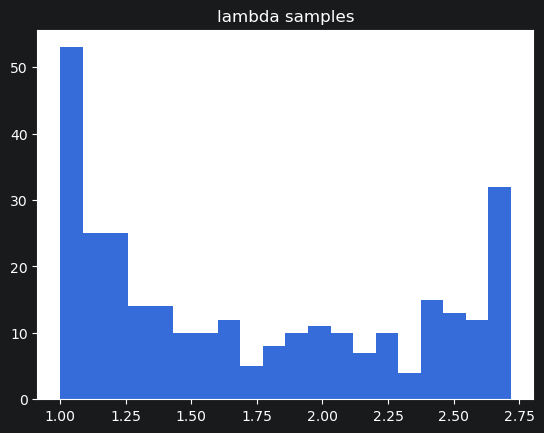

In [24]:
print(train_map_estimates_collection["ou_params"]["lambd"])
plt.hist(train_map_estimates_collection["ou_params"]["lambd"].flatten(),bins=20)
plt.title("lambda samples")

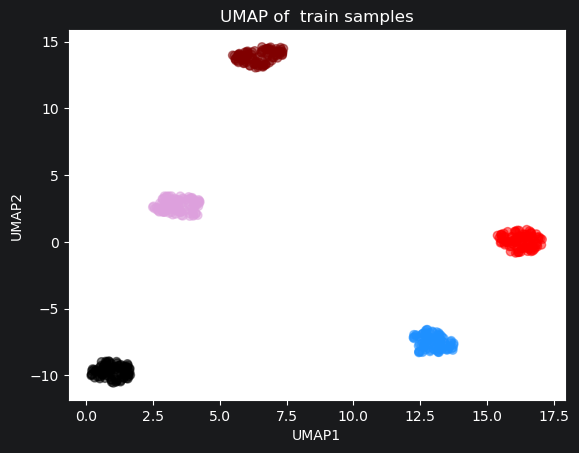

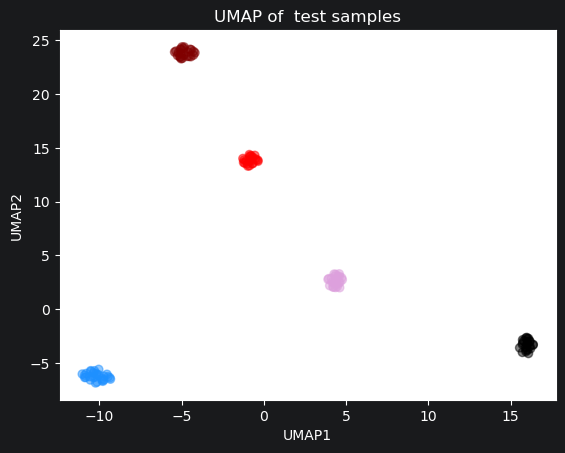

In [25]:
color_map21 = matplotlib.colors.ListedColormap(
    ["plum", "navy", "turquoise", "peachpuff", "palevioletred", "red", "darkorange", "yellow", "lime", "green",
     "dodgerblue", "blue", "purple", "magenta", "grey", "maroon", "lightcoral", "olive", "teal", "goldenrod",
     "black"], name="21colormap")
if "21colormap" not in matplotlib.pyplot.colormaps():
    plt.colormaps.register(cmap=color_map21)
color_map148 = matplotlib.colors.ListedColormap(list(matplotlib.colors.CSS4_COLORS.values()), name="148colormap")
if "148colormap" not in matplotlib.pyplot.colormaps():
    plt.colormaps.register(cmap=color_map148)
plt.rcParams['axes.facecolor'] = 'white'

def plot_umap(samples, labels, title):
    reducer = umap.UMAP()
    samples_2d = reducer.fit_transform(samples)

    n_unique = len(np.unique(labels))

    color_map_name = "nipy_spectral" if n_unique > 148 else "148colormap" if n_unique > 21 else "21colormap"
    colors = plt.get_cmap(color_map_name, n_unique).colors.tolist()
    colors = [matplotlib.colors.to_hex(color) for color in colors]
    colors_dict = dict(zip(list(range(n_unique)), colors))
    colors_labels = np.vectorize(colors_dict.get)(labels)

    plt.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.5,color=colors_labels)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    plt.title(f'UMAP of  {title} samples')
    plt.show()

plot_umap(train_map_estimates_collection["train"]["latent_space"][:,0], y_train,"train") #we plot 1 sample per sequence
plot_umap(test_latent_samples[:,0], y_test, "test")
